# Fig. 3(b) Reproduction With `bloqade-decoders`

This notebook reproduces the Gemini logical simulator workflow for Fig. 3(b) of `arXiv:2412.15165v1`, while using the decoder implementations from the local `bloqade-decoders` checkout instead of notebook-local decoder code.

What is notebook-local vs decoder-local here:
- The Gemini logical hardware kernels, detector mappings, simulator tasks, tomography, and plotting live in this notebook.
- The MLE decoder is `GurobiDecoder` from the local `bloqade-decoders` repo, using its paper-style logical-gap confidence score.
- The MLD decoder is `TableDecoder` from the local `bloqade-decoders` repo, trained from simulator samples. Its confidence score here is the empirical posterior mass of the selected logical correction for a given detector syndrome.

Notes:
- The paper's exact MLD postselection ranks syndrome patterns by the output fidelity they induce. In this notebook we instead use the decoder-native confidence available from `TableDecoder`'s learned counts.
- The notebook prepends the sibling `../bloqade-decoders/src` path so it uses the current working tree, including the new MLE logical-gap support.
- The default configuration is interactive rather than paper-scale.


In [1]:
import math
import sys
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import stim
from beliefmatching import detector_error_model_to_check_matrices
from bloqade import qubit, squin
from bloqade.gemini import logical as gemini_logical
from bloqade.gemini.logical.stdlib import default_post_processing
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.lanes.analysis import atom
from bloqade.lanes.arch.gemini.impls import generate_arch_hypercube
from bloqade.lanes.device import GeminiLogicalSimulatorTask
from bloqade.lanes.logical_mvp import append_measurements_and_annotations, compile_squin_to_move
from bloqade.lanes.steane_defaults import steane7_m2dets, steane7_m2obs
from kirin.dialects import ilist
from scipy.special import logsumexp

LOCAL_DECODER_SRC_CANDIDATES = [
    Path.cwd() / '..' / 'bloqade-decoders' / 'src',
    Path.cwd() / 'bloqade-decoders' / 'src',
    Path.cwd().parent / 'bloqade-decoders' / 'src',
    Path.cwd().parent.parent / 'bloqade-decoders' / 'src',
]
for candidate in LOCAL_DECODER_SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate sibling bloqade-decoders/src checkout.')

import bloqade.decoders as bloqade_decoders
from bloqade.decoders import GurobiDecoder, TableDecoder

print('Using bloqade.decoders from:', Path(bloqade_decoders.__file__).resolve())


Using bloqade.decoders from: /Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-decoders/src/bloqade/decoders/__init__.py


In [2]:
FAST_CONFIG = {
    'mld_train_shots': 20_000,
    'eval_shots': 4_000,
    'posterior_samples': 20_000,
    'mle_threshold_points': 24,
    'mld_threshold_points': 24,
}

PAPER_SCALE_CONFIG = {
    'mld_train_shots': 1_000_000_000,
    'eval_shots': 250_000,
    'posterior_samples': 200_000,
    'mle_threshold_points': 64,
    'mld_threshold_points': 64,
}

CONFIG = FAST_CONFIG.copy()

BASIS_LABELS = ('X', 'Y', 'Z')
OUTPUT_QUBIT = 0
ANCILLA_QUBITS = (1, 2, 3, 4)
FACTORY_TARGET = np.array([0, 0, 1, 1], dtype=np.uint8)
SQRT3 = np.sqrt(3.0)

M2DETS_5 = steane7_m2dets(5)
M2OBS_5 = steane7_m2obs(5)
M2DETS_1 = steane7_m2dets(1)
M2OBS_1 = steane7_m2obs(1)


def bits_to_key(bits: np.ndarray | list[bool] | list[int]) -> str:
    return ''.join('1' if int(x) else '0' for x in bits)


def key_to_bits(key: str) -> np.ndarray:
    return np.fromiter((1 if c == '1' else 0 for c in key), dtype=np.uint8)


def logical_expectation(bits: np.ndarray) -> float:
    if len(bits) == 0:
        return float('nan')
    return float(np.mean(1.0 - 2.0 * bits.astype(np.float64)))


def pack_boolean_array(arr: np.ndarray) -> np.ndarray:
    return np.sum(arr.astype(np.uint64) << np.arange(arr.shape[1], dtype=np.uint64), axis=1)


@squin.kernel
def msd_magic_prep(reg):
    squin.broadcast.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg)


@squin.kernel
def msd_forward(reg):
    squin.broadcast.sqrt_x(ilist.IList([reg[0], reg[1], reg[4]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[2]]), ilist.IList([reg[1], reg[3]]))
    squin.broadcast.sqrt_y(ilist.IList([reg[0], reg[3]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[3]]), ilist.IList([reg[2], reg[4]]))
    squin.sqrt_x_adj(reg[0])
    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[4], reg[3]]))
    squin.broadcast.sqrt_y_adj(reg)


@squin.kernel
def msd_inverse(reg):
    squin.broadcast.sqrt_y(reg)
    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[4], reg[3]]))
    squin.sqrt_x(reg[0])
    squin.broadcast.cz(ilist.IList([reg[0], reg[3]]), ilist.IList([reg[2], reg[4]]))
    squin.broadcast.sqrt_y_adj(ilist.IList([reg[0], reg[3]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[2]]), ilist.IList([reg[1], reg[3]]))
    squin.broadcast.sqrt_x_adj(ilist.IList([reg[0], reg[1], reg[4]]))


@squin.kernel
def prepare_special_x(reg):
    squin.h(reg[OUTPUT_QUBIT])
    msd_inverse(reg)


@squin.kernel
def prepare_special_y(reg):
    squin.sqrt_x(reg[OUTPUT_QUBIT])
    msd_inverse(reg)


@squin.kernel
def prepare_special_z(reg):
    msd_inverse(reg)


@squin.kernel
def tomography_x(reg):
    squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))


@squin.kernel
def tomography_y(reg):
    squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))
    squin.sqrt_z_adj(reg[OUTPUT_QUBIT])


@squin.kernel
def tomography_z(reg):
    squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))
    squin.h(reg[OUTPUT_QUBIT])


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_x():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_y():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_z():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_x():
    reg = qubit.qalloc(5)
    prepare_special_x(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_y():
    reg = qubit.qalloc(5)
    prepare_special_y(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_z():
    reg = qubit.qalloc(5)
    prepare_special_z(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_x():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_y():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    squin.sqrt_z_adj(reg[0])
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_z():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    squin.h(reg[0])
    return default_post_processing(reg)


ACTUAL_KERNELS = {'X': msd_actual_x, 'Y': msd_actual_y, 'Z': msd_actual_z}
SPECIAL_KERNELS = {'X': msd_special_x, 'Y': msd_special_y, 'Z': msd_special_z}
INJECTED_KERNELS = {'X': injected_x, 'Y': injected_y, 'Z': injected_z}


In [3]:
@dataclass
class BasisDataset:
    detectors: np.ndarray
    observables: np.ndarray

# def run_task(task, shots: int, with_noise: bool = True, chunk_size: int = 512):
#     det_chunks = []
#     obs_chunks = []

#     remaining = shots
#     while remaining > 0:
#         batch = min(chunk_size, remaining)
#         result = task.run(batch, with_noise=with_noise, run_detectors=True)
#         det_chunks.append(np.asarray(result.detectors, dtype=np.uint8))
#         obs_chunks.append(np.asarray(result.observables, dtype=np.uint8))
#         remaining -= batch

#     det = np.concatenate(det_chunks, axis=0)
#     obs = np.concatenate(obs_chunks, axis=0)
#     return BasisDataset(det, obs)


def run_task(task, shots: int, with_noise: bool = True):
    result = task.run(shots, with_noise=with_noise, run_detectors=True)
    print(f"run_task, result was created")
    det = np.asarray(result.detectors, dtype=np.uint8)
    print(f"run_task, det was created")
    obs = np.asarray(result.observables, dtype=np.uint8)
    print(f"run_task, obs was created")
    return BasisDataset(det, obs)


def split_factory_bits(detectors: np.ndarray, observables: np.ndarray):
    anc_det = detectors[:, 3:]
    anc_obs = observables[:, 1:]
    return anc_det, anc_obs


def make_shape_only_dem(num_detectors: int, num_observables: int) -> stim.DetectorErrorModel:
    terms = []
    if num_detectors:
        terms.append(' '.join(f'D{i}' for i in range(num_detectors)))
    if num_observables:
        terms.append(' '.join(f'L{i}' for i in range(num_observables)))
    if not terms:
        raise ValueError('Need at least one detector or observable.')
    return stim.DetectorErrorModel('\n'.join(f'error(0.5) {term}' for term in terms))


def matrix_to_dem(check_matrix: np.ndarray, observables_matrix: np.ndarray, priors: np.ndarray) -> stim.DetectorErrorModel:
    lines = []
    for col, prior in enumerate(np.asarray(priors, dtype=np.float64)):
        det_targets = [f'D{i}' for i in np.flatnonzero(check_matrix[:, col])]
        obs_targets = [f'L{i}' for i in np.flatnonzero(observables_matrix[:, col])]
        if not det_targets and not obs_targets:
            continue
        safe_prior = float(np.clip(prior, 1e-12, 1.0 - 1e-12))
        lines.append(f"error({safe_prior:.16g}) " + ' '.join(det_targets + obs_targets))
    if not lines:
        raise ValueError('Matrix reduction produced an empty DEM.')
    return stim.DetectorErrorModel('\n'.join(lines))


def compute_dem_data(task):
    dem_matrix = detector_error_model_to_check_matrices(
        task.detector_error_model,
        allow_undecomposed_hyperedges=True,
    )
    return {
        'H': dem_matrix.check_matrix.toarray().astype(np.int64),
        'O': dem_matrix.observables_matrix.toarray().astype(np.int64),
        'priors': np.asarray(dem_matrix.priors, dtype=np.float64),
    }


def empirical_table_confidence(decoder: TableDecoder, detector_bits: np.ndarray) -> float:
    num_dets = decoder.num_detectors
    num_obs = decoder.num_observables
    counts = decoder.det_obs_counts.reshape(1 << num_obs, 1 << num_dets)
    packed = int(pack_boolean_array(np.asarray(detector_bits, dtype=bool).reshape(1, -1))[0])
    syndrome_counts = counts[:, packed]
    total = int(syndrome_counts.sum())
    if total == 0:
        return 0.0
    return float(np.max(syndrome_counts) / total)


def build_mld_decoders(training_dataset: BasisDataset):
    anc_det, anc_obs = split_factory_bits(training_dataset.detectors, training_dataset.observables)

    full_decoder = TableDecoder.from_det_obs_shots(
        make_shape_only_dem(training_dataset.detectors.shape[1], training_dataset.observables.shape[1]),
        np.concatenate([training_dataset.detectors, training_dataset.observables], axis=1).astype(bool),
    )
    factory_decoder = TableDecoder.from_det_obs_shots(
        make_shape_only_dem(anc_det.shape[1], anc_obs.shape[1]),
        np.concatenate([anc_det, anc_obs], axis=1).astype(bool),
    )

    @lru_cache(maxsize=None)
    def decode_factory(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(factory_decoder.decode(syndrome), dtype=np.uint8)
        confidence = empirical_table_confidence(factory_decoder, syndrome)
        return tuple(int(x) for x in correction.tolist()), confidence

    @lru_cache(maxsize=None)
    def decode_full(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(full_decoder.decode(syndrome), dtype=np.uint8)
        return tuple(int(x) for x in correction.tolist())

    return {
        'full_decoder': full_decoder,
        'factory_decoder': factory_decoder,
        'decode_factory': decode_factory,
        'decode_full': decode_full,
    }


def build_mle_decoders(task):
    dem_data = compute_dem_data(task)
    full_dem = matrix_to_dem(dem_data['H'], dem_data['O'], dem_data['priors'])
    factory_dem = matrix_to_dem(dem_data['H'][3:, :], dem_data['O'][1:, :], dem_data['priors'])

    full_decoder = GurobiDecoder(full_dem)
    factory_decoder = GurobiDecoder(factory_dem)

    @lru_cache(maxsize=None)
    def decode_factory(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction, logical_gap = factory_decoder.decode(syndrome, return_logical_gap=True)
        correction = np.asarray(correction, dtype=np.uint8)
        logical_gap = np.asarray(logical_gap, dtype=np.float64)
        return tuple(int(x) for x in correction.tolist()), float(logical_gap[0])

    @lru_cache(maxsize=None)
    def decode_full(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(full_decoder.decode(syndrome), dtype=np.uint8)
        return tuple(int(x) for x in correction.tolist())

    return {
        'full_decoder': full_decoder,
        'factory_decoder': factory_decoder,
        'decode_factory': decode_factory,
        'decode_full': decode_full,
    }


def weighted_quantile(values: np.ndarray, quantiles: list[float], weights: np.ndarray):
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf /= cdf[-1]
    return np.interp(quantiles, cdf, values)


def sample_bloch_ball(num_samples: int, seed: int = 1234) -> np.ndarray:
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(num_samples, 3))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = rng.random(num_samples) ** (1.0 / 3.0)
    return directions * radii[:, None]


def fidelity_from_counts(x_bits: np.ndarray, y_bits: np.ndarray, z_bits: np.ndarray, posterior_samples: int):
    ex = logical_expectation(x_bits)
    ey = logical_expectation(y_bits)
    ez = logical_expectation(z_bits)
    point = 0.5 + (ex + ey + ez) / (2.0 * SQRT3)

    n = np.array([len(x_bits), len(y_bits), len(z_bits)], dtype=np.int64)
    k = np.array([
        int(np.sum(x_bits == 0)),
        int(np.sum(y_bits == 0)),
        int(np.sum(z_bits == 0)),
    ], dtype=np.int64)

    points = sample_bloch_ball(posterior_samples)
    probs = np.clip((1.0 + points) / 2.0, 1e-12, 1.0 - 1e-12)
    log_weights = (k * np.log(probs) + (n - k) * np.log1p(-probs)).sum(axis=1)
    weights = np.exp(log_weights - logsumexp(log_weights))
    fidelities = 0.5 + np.sum(points, axis=1) / (2.0 * SQRT3)
    q16, q50, q84 = weighted_quantile(fidelities, [0.16, 0.5, 0.84], weights)
    return {
        'point': float(point),
        'median': float(q50),
        'low': float(q16),
        'high': float(q84),
        'bloch': (float(ex), float(ey), float(ez)),
    }


def evaluate_curve(actual_data, decoder_map, posterior_samples: int, threshold_points: int, metric: str):
    all_scores = []
    for basis in BASIS_LABELS:
        dataset = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)
        decode_factory = decoder_map[basis]['decode_factory']
        for a_det, a_obs in zip(anc_det, anc_obs, strict=True):
            anc_flip, score = decode_factory(bits_to_key(a_det))
            anc_flip = np.asarray(anc_flip, dtype=np.uint8)
            if np.array_equal(a_obs ^ anc_flip, FACTORY_TARGET) and np.isfinite(score):
                all_scores.append(score)
    if not all_scores:
        raise RuntimeError(f'No factory-accepted shots found for {metric} threshold sweep')

    thresholds = np.unique(np.quantile(np.asarray(all_scores), np.linspace(0.0, 1.0, threshold_points)))
    accepted_fractions = []
    fidelities = []
    credibility = []

    for threshold in thresholds:
        corrected = {}
        total_kept = 0
        total_shots = 0
        for basis in BASIS_LABELS:
            dataset = actual_data[basis]
            anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)
            decode_factory = decoder_map[basis]['decode_factory']
            decode_full = decoder_map[basis]['decode_full']
            corrected_bits = []
            for det, obs, a_det, a_obs in zip(dataset.detectors, dataset.observables, anc_det, anc_obs, strict=True):
                anc_flip, score = decode_factory(bits_to_key(a_det))
                anc_flip = np.asarray(anc_flip, dtype=np.uint8)
                corrected_anc = a_obs ^ anc_flip
                if not np.array_equal(corrected_anc, FACTORY_TARGET):
                    continue
                if score < threshold:
                    continue
                full_flip = np.asarray(decode_full(bits_to_key(det)), dtype=np.uint8)
                corrected_bits.append(int(obs[0] ^ full_flip[0]))
            corrected[basis] = np.asarray(corrected_bits, dtype=np.uint8)
            total_kept += len(corrected[basis])
            total_shots += len(dataset.observables)
        if min(len(corrected[b]) for b in BASIS_LABELS) == 0:
            continue
        accepted_fractions.append(total_kept / total_shots)
        summary = fidelity_from_counts(corrected['X'], corrected['Y'], corrected['Z'], posterior_samples)
        fidelities.append(summary['point'])
        credibility.append((summary['low'], summary['high']))

    return {
        'accepted_fraction': np.asarray(accepted_fractions, dtype=np.float64),
        'fidelity': np.asarray(fidelities, dtype=np.float64),
        'credible': np.asarray(credibility, dtype=np.float64),
    }


def injected_baseline(task_map, posterior_samples: int):
    corrected = {}
    for basis in BASIS_LABELS:
        task = task_map[basis]
        dataset = run_task(task, CONFIG['eval_shots'], with_noise=True)
        decoder = TableDecoder.from_det_obs_shots(
            make_shape_only_dem(dataset.detectors.shape[1], dataset.observables.shape[1]),
            np.concatenate([dataset.detectors, dataset.observables], axis=1).astype(bool),
        )
        bits = []
        for det, obs in zip(dataset.detectors, dataset.observables, strict=True):
            flip = np.asarray(decoder.decode(det.astype(bool)), dtype=np.uint8)
            bits.append(int(obs[0] ^ flip[0]))
        corrected[basis] = np.asarray(bits, dtype=np.uint8)
    return fidelity_from_counts(corrected['X'], corrected['Y'], corrected['Z'], posterior_samples)


In [4]:
def build_task(simulator: GeminiLogicalSimulator, kernel, *, m2dets, m2obs):
    logical_kernel = kernel.similar()
    # TODO: maybe conditionally apply append_measurements_and_annotations ?
    # append_measurements_and_annotations(logical_kernel, m2dets, m2obs)
    physical_arch_spec = generate_arch_hypercube(4)
    physical_move_kernel = compile_squin_to_move(
        logical_kernel,
        transversal_rewrite=True,
    )
    post_processing = atom.AtomInterpreter(
        physical_move_kernel.dialects,
        arch_spec=physical_arch_spec,
    ).get_post_processing(physical_move_kernel)
    return GeminiLogicalSimulatorTask(
        logical_kernel,
        simulator.noise_model,
        physical_arch_spec,
        physical_move_kernel,
        post_processing,
    )


sim = GeminiLogicalSimulator()

actual_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_5, m2obs=M2OBS_5)
    for basis, kernel in ACTUAL_KERNELS.items()
}
special_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_5, m2obs=M2OBS_5)
    for basis, kernel in SPECIAL_KERNELS.items()
}
injected_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_1, m2obs=M2OBS_1)
    for basis, kernel in INJECTED_KERNELS.items()
}

print('Compiled tasks:')
print(' actual:', list(actual_tasks))
print(' special:', list(special_tasks))
print(' injected:', list(injected_tasks))

for basis, task in special_tasks.items():
    data = run_task(task, 64, with_noise=False)
    print(basis, 'special-state noiseless observables:', sorted({tuple(row) for row in data.observables}))


Compiled tasks:
 actual: ['X', 'Y', 'Z']
 special: ['X', 'Y', 'Z']
 injected: ['X', 'Y', 'Z']
run_task, result was created
run_task, det was created
run_task, obs was created
X special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0)), (np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(1)), (np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(0)), (np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(1)), (np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(0)), (np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(1)), (np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(1), np.uint8(0)), (np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(1), np.uint8(1)), (np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(0), np.uint8(0)), (np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(0), np.uint8(1)), (np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(1), np.uint8(0)), (np.uint8(0), np.uint8(1), np.uint8(1), np.uint8

In [5]:
ACTUAL_KERNELS, SPECIAL_KERNELS, INJECTED_KERNELS

({'X': Method("msd_actual_x"),
  'Y': Method("msd_actual_y"),
  'Z': Method("msd_actual_z")},
 {'X': Method("msd_special_x"),
  'Y': Method("msd_special_y"),
  'Z': Method("msd_special_z")},
 {'X': Method("injected_x"),
  'Y': Method("injected_y"),
  'Z': Method("injected_z")})

In [6]:
type(special_tasks)

dict

In [7]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x121cbff50>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [8]:
x_task_test = special_tasks["X"]

In [9]:
from IPython.display import HTML, display

diagram = x_task_test.tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [10]:
x_task_test.run(1, with_noise=False, run_detectors=True)

DetectorResult(_detector_error_model=stim.DetectorErrorModel('''
    error(0.040493) D0 D1 D2
    error(0.00114223) D0 D1 D2 D3 D4 D5
    error(0.00824167) D0 D1 D2 D6 D7 D8
    error(0.00253413) D0 D1 D2 D6 D7 D8 D9 D10 D11
    error(0.00114223) D0 D1 D2 D9 D10 D11 D12 D13 D14
    error(0.0208756) D0 D1 D2 D12 D13 D14
    error(0.00114223) D0 D1 D3 D4 L0 L1
    error(0.00253413) D0 D1 D6 D7 D9 D10 L0 L2 L3
    error(0.00824167) D0 D1 D6 D7 L0 L2
    error(0.00114223) D0 D1 D9 D10 D12 D13 L0 L3 L4
    error(0.0208756) D0 D1 D12 D13 L0 L4
    error(0.040493) D0 D1 L0
    error(0.040493) D0 D2
    error(0.00114223) D0 D2 D3 D5
    error(0.00824167) D0 D2 D6 D8
    error(0.00253413) D0 D2 D6 D8 D9 D11
    error(0.00114223) D0 D2 D9 D11 D12 D14
    error(0.0208756) D0 D2 D12 D14
    error(0.00114223) D0 D3 L0 L1
    error(0.00253413) D0 D6 D9 L0 L2 L3
    error(0.00824167) D0 D6 L0 L2
    error(0.00114223) D0 D9 D12 L0 L3 L4
    error(0.0208756) D0 D12 L0 L4
    error(0.040493) D0 L0
    e

In [11]:
x_task_test.run(1, with_noise=True, run_detectors=True)

DetectorResult(_detector_error_model=stim.DetectorErrorModel('''
    error(0.040493) D0 D1 D2
    error(0.00114223) D0 D1 D2 D3 D4 D5
    error(0.00824167) D0 D1 D2 D6 D7 D8
    error(0.00253413) D0 D1 D2 D6 D7 D8 D9 D10 D11
    error(0.00114223) D0 D1 D2 D9 D10 D11 D12 D13 D14
    error(0.0208756) D0 D1 D2 D12 D13 D14
    error(0.00114223) D0 D1 D3 D4 L0 L1
    error(0.00253413) D0 D1 D6 D7 D9 D10 L0 L2 L3
    error(0.00824167) D0 D1 D6 D7 L0 L2
    error(0.00114223) D0 D1 D9 D10 D12 D13 L0 L3 L4
    error(0.0208756) D0 D1 D12 D13 L0 L4
    error(0.040493) D0 D1 L0
    error(0.040493) D0 D2
    error(0.00114223) D0 D2 D3 D5
    error(0.00824167) D0 D2 D6 D8
    error(0.00253413) D0 D2 D6 D8 D9 D11
    error(0.00114223) D0 D2 D9 D11 D12 D14
    error(0.0208756) D0 D2 D12 D14
    error(0.00114223) D0 D3 L0 L1
    error(0.00253413) D0 D6 D9 L0 L2 L3
    error(0.00824167) D0 D6 L0 L2
    error(0.00114223) D0 D9 D12 L0 L3 L4
    error(0.0208756) D0 D12 L0 L4
    error(0.040493) D0 L0
    e

In [12]:
result = x_task_test.run(20000, with_noise=False, run_detectors=True)

In [13]:
det = np.asarray(result.detectors, dtype=np.uint8)

In [14]:
obs = np.asarray(result.observables, dtype=np.uint8)

In [15]:
result_noisy = x_task_test.run(20000, with_noise=True, run_detectors=True)

In [16]:
det_noisy = np.asarray(result_noisy.detectors, dtype=np.uint8)

In [17]:
obs_noisy = np.asarray(result.observables, dtype=np.uint8)

In [18]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x121cbff50>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [19]:
# Conservative cell
# CONFIG['mld_train_shots'] = 5000

In [20]:
def build_mld_decoders_debug(training_dataset: BasisDataset):
    print("det shape/dtype:", training_dataset.detectors.shape, training_dataset.detectors.dtype)
    print("obs shape/dtype:", training_dataset.observables.shape, training_dataset.observables.dtype)

    det = np.ascontiguousarray(training_dataset.detectors, dtype=bool)
    obs = np.ascontiguousarray(training_dataset.observables, dtype=bool)
    print("det contiguous:", det.flags["C_CONTIGUOUS"], det.nbytes)
    print("obs contiguous:", obs.flags["C_CONTIGUOUS"], obs.nbytes)

    anc_det, anc_obs = split_factory_bits(det, obs)
    print("anc det/obs:", anc_det.shape, anc_obs.shape)

    full_dem = make_shape_only_dem(det.shape[1], obs.shape[1])
    factory_dem = make_shape_only_dem(anc_det.shape[1], anc_obs.shape[1])
    print("dem sizes:", full_dem.num_detectors, full_dem.num_observables, factory_dem.num_detectors, factory_dem.num_observables)

    full_shots = np.ascontiguousarray(np.concatenate([det, obs], axis=1), dtype=bool)
    factory_shots = np.ascontiguousarray(np.concatenate([anc_det, anc_obs], axis=1), dtype=bool)
    print("full shots:", full_shots.shape, full_shots.dtype, full_shots.nbytes)
    print("factory shots:", factory_shots.shape, factory_shots.dtype, factory_shots.nbytes)

    print("building full decoder...")
    full_decoder = TableDecoder.from_det_obs_shots(full_dem, full_shots)
    print("built full decoder:", full_decoder.det_obs_counts.shape, full_decoder.det_obs_counts.nbytes)

    print("building factory decoder...")
    factory_decoder = TableDecoder.from_det_obs_shots(factory_dem, factory_shots)
    print("built factory decoder:", factory_decoder.det_obs_counts.shape, factory_decoder.det_obs_counts.nbytes)

    return full_decoder, factory_decoder


In [21]:
# dataset = run_task(special_tasks["X"], 20000, with_noise=True)
# full_decoder, factory_decoder = build_mld_decoders_debug(dataset)

In [22]:
mld_training = {}
for basis, task in special_tasks.items():
    print(f"Sampling MLD training data for {basis} with {CONFIG['mld_train_shots']:,} shots...")
    dataset = run_task(task, CONFIG['mld_train_shots'], with_noise=True)
    print(f"dataset was created")
    mld_training[basis] = build_mld_decoders(dataset)
    print(f"built mld decoder")

Sampling MLD training data for X with 20,000 shots...
run_task, result was created
run_task, det was created
run_task, obs was created
dataset was created
built mld decoder
Sampling MLD training data for Y with 20,000 shots...
run_task, result was created
run_task, det was created
run_task, obs was created
dataset was created
built mld decoder
Sampling MLD training data for Z with 20,000 shots...
run_task, result was created
run_task, det was created
run_task, obs was created
dataset was created
built mld decoder


In [23]:


actual_data = {
    basis: run_task(task, CONFIG['eval_shots'], with_noise=True)
    for basis, task in actual_tasks.items()
}

mle_decoders = {
    basis: build_mle_decoders(task)
    for basis, task in actual_tasks.items()
}

mld_curve = evaluate_curve(
    actual_data,
    mld_training,
    CONFIG['posterior_samples'],
    CONFIG['mld_threshold_points'],
    metric='MLD confidence',
)
mle_curve = evaluate_curve(
    actual_data,
    mle_decoders,
    CONFIG['posterior_samples'],
    CONFIG['mle_threshold_points'],
    metric='MLE logical gap',
)
injected_summary = injected_baseline(injected_tasks, CONFIG['posterior_samples'])

print('Injected baseline fidelity:', injected_summary['point'])
print('MLE curve points:', len(mle_curve['accepted_fraction']))
print('MLD curve points:', len(mld_curve['accepted_fraction']))


run_task, result was created
run_task, det was created
run_task, obs was created
run_task, result was created
run_task, det was created
run_task, obs was created
run_task, result was created
run_task, det was created
run_task, obs was created
Restricted license - for non-production use only - expires 2027-11-29
run_task, result was created
run_task, det was created
run_task, obs was created
run_task, result was created
run_task, det was created
run_task, obs was created
run_task, result was created
run_task, det was created
run_task, obs was created
Injected baseline fidelity: 0.9949335182628067
MLE curve points: 9
MLD curve points: 5


In [25]:
for basis, task in injected_tasks.items():
    data = run_task(task, 1000, with_noise=False)
    print(basis, np.mean(1 - 2 * data.observables[:, 0]))

run_task, result was created
run_task, det was created
run_task, obs was created
X 55.61
run_task, result was created
run_task, det was created
run_task, obs was created
Y 56.372
run_task, result was created
run_task, det was created
run_task, obs was created
Z 58.15


In [26]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

run_task, result was created
run_task, det was created
run_task, obs was created
X [[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 0]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 0 0]
 [1 1 1 0 1]
 [1 1 1 1 0]
 [1 1 1 1 1]]
run_task, result was created
run_task, det was created
run_task, obs was created
Y [[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 0]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 0 0]
 [1 1 1 0 1]
 [1 1 1 1 0]
 [1 1 1 1 1]]


In [27]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "output unique:", np.unique(data.observables[:, 0]))
    print(basis, "ancilla unique rows:", np.unique(data.observables[:, 1:], axis=0))

run_task, result was created
run_task, det was created
run_task, obs was created
X output unique: [0 1]
X ancilla unique rows: [[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]
run_task, result was created
run_task, det was created
run_task, obs was created
Y output unique: [0 1]
Y ancilla unique rows: [[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]
run_task, result was created
run_task, det was created
run_task, obs was created
Z output unique: [0 1]
Z ancilla unique rows: [[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]


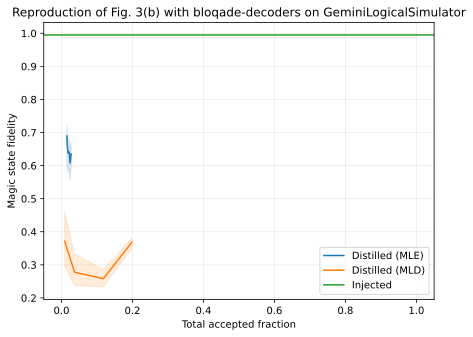

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mle_curve['accepted_fraction'], mle_curve['fidelity'], color='tab:blue', label='Distilled (MLE)')
ax.fill_between(
    mle_curve['accepted_fraction'],
    mle_curve['credible'][:, 0],
    mle_curve['credible'][:, 1],
    color='tab:blue',
    alpha=0.15,
)

ax.plot(mld_curve['accepted_fraction'], mld_curve['fidelity'], color='tab:orange', label='Distilled (MLD)')
ax.fill_between(
    mld_curve['accepted_fraction'],
    mld_curve['credible'][:, 0],
    mld_curve['credible'][:, 1],
    color='tab:orange',
    alpha=0.15,
)

ax.axhline(injected_summary['point'], color='tab:green', linestyle='-', label='Injected')
ax.fill_between(
    [0.0, 1.0],
    injected_summary['low'],
    injected_summary['high'],
    color='tab:green',
    alpha=0.1,
)

ax.set_xlabel('Total accepted fraction')
ax.set_ylabel('Magic state fidelity')
ax.set_title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


# Debugging why the plot is bad